#                                               **File assumed as plant 1 is- 'Copy of PPT 25-26'**

# **Objective**: Analyze plant performance using monthly SCADA data
# **KPIs**: CUF, PR, Specific Yield, Correlation

## I have started with April 2025 month sheet from Plant 1 and then will automate the results for all the months later

## Data Cleaning and Optimisation

### STEP 0: First, just load the file

In [1]:
import pandas as pd

file = "Copy of PPT 25-26.xlsx"

### STEP 1: Checking sheet names and found one hidden sheet

In [2]:
xls = pd.ExcelFile(file)
print(xls.sheet_names)

['Master', 'GHI distribution', 'Apr-25', 'May-25', 'Jun-25', 'July-2025', 'Aug-2025', 'Sep-25', 'Oct-25', 'Nov-25']


In [3]:
xls.parse('GHI distribution').head()

,City,Telangana,Unnamed: 2,Unnamed: 3,Year,month,day,GHI,TEMP,city,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Lat Long,"17.433708202151262, 78.48972021282965",NaN,NaN,2024,4,1,6.5282,32.76,Telangana,NaN,2024.0,4.0,6.087400,0.101354
1,NaN,NaN,NaN,NaN,2024,4,2,6.2076,33.40,Telangana,NaN,2024.0,5.0,6.225168,0.103647
2,NaN,NaN,NaN,NaN,2024,4,3,5.2519,32.87,Telangana,NaN,2024.0,6.0,5.012863,0.083463
3,NaN,NaN,NaN,NaN,2024,4,4,6.2772,33.65,Telangana,NaN,2024.0,7.0,3.808955,0.063418
4,NaN,NaN,NaN,NaN,2024,4,5,6.4385,34.56,Telangana,NaN,2024.0,8.0,4.401361,0.073282


### STEP 2: Read Apr-25 sheet for separate Analysis of April month first

In [4]:
df = pd.read_excel(file, sheet_name='Apr-25', header=None)
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DC Capacity,127.53,129.16,129.16,129.16,129.16,129.16,129.16,129.16,134.07,...,132.98,128.07,134.61,128.62,128.62,132.98,133.52,2340.18,NaN,NaN
2,Date,Inverter 1,Inverter 2,Inverter 3,Inverter 4,Inverter 5,Inverter 6,Inverter 7,Inverter 8,Inverter 9,...,Inverter 12,Inverter 13,Inverter 14,Inverter 15,Inverter 16,Inverter 17,Inverter 18,Actual Total kWh,Energy Meter Export,GHI kW/m2
3,2025-04-01 00:00:00,136.7,137,135.5,136.09,45.4,43.9,135.2,136.2,0,...,137.2,43,136.9,135.5,136.7,137.31,137.2,2043.0,NaN,6.67
4,2025-04-02 00:00:00,22.8,22.6,22.7,22.6,17.3,17.11,22.4,22.8,0,...,22.7,17.5,22.5,22.5,22.5,22.7,22.6,697,NaN,6.27
5,2025-04-03 00:00:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,542,NaN,2.67
6,2025-04-04 00:00:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,489,NaN,6.62
7,2025-04-05 00:00:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,893,NaN,6.42
8,2025-04-06 00:00:00,6,5.9,5.9,5.5,4.8,4.6,5.5,5.5,0,...,5.6,4.7,5.7,5.7,5.5,5.8,5.9,94,NaN,6.85
9,2025-04-07 00:00:00,72.3,72.2,72.41,72.5,20.9,19.8,73,73,0,...,72.6,20.9,72.7,72.8,72.91,73.6,73.2,1077.83,NaN,6.36


### STEP 3: Fixing of headers and telling python Row 2 is my column names

In [5]:
df = pd.read_excel(file, sheet_name='Apr-25', header=2)
df.head()

,Date,Inverter 1,Inverter 2,Inverter 3,Inverter 4,Inverter 5,Inverter 6,Inverter 7,Inverter 8,Inverter 9,...,Inverter 12,Inverter 13,Inverter 14,Inverter 15,Inverter 16,Inverter 17,Inverter 18,Actual Total kWh,Energy Meter Export,GHI kW/m2
0,2025-04-01 00:00:00,136.7,137.0,135.5,136.09,45.4,43.90,135.2,136.2,0,...,137.2,43.0,136.9,135.5,136.7,137.31,137.2,2043.0,NaN,6.67
1,2025-04-02 00:00:00,22.8,22.6,22.7,22.60,17.3,17.11,22.4,22.8,0,...,22.7,17.5,22.5,22.5,22.5,22.70,22.6,697.0,NaN,6.27
2,2025-04-03 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,542.0,NaN,2.67
3,2025-04-04 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,489.0,NaN,6.62
4,2025-04-05 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,893.0,NaN,6.42


In [6]:
print(df.columns)
df.head()

Index(['Date', 'Inverter 1', 'Inverter 2', 'Inverter 3', 'Inverter 4',
       'Inverter 5', 'Inverter 6', 'Inverter 7', 'Inverter 8', 'Inverter 9',
       'Inverter 10', 'Inverter 11', 'Inverter 12', 'Inverter 13',
       'Inverter 14', 'Inverter 15', 'Inverter 16', 'Inverter 17',
       'Inverter 18', 'Actual Total kWh', 'Energy Meter Export', 'GHI kW/m2'],
      dtype='object')


,Date,Inverter 1,Inverter 2,Inverter 3,Inverter 4,Inverter 5,Inverter 6,Inverter 7,Inverter 8,Inverter 9,...,Inverter 12,Inverter 13,Inverter 14,Inverter 15,Inverter 16,Inverter 17,Inverter 18,Actual Total kWh,Energy Meter Export,GHI kW/m2
0,2025-04-01 00:00:00,136.7,137.0,135.5,136.09,45.4,43.90,135.2,136.2,0,...,137.2,43.0,136.9,135.5,136.7,137.31,137.2,2043.0,NaN,6.67
1,2025-04-02 00:00:00,22.8,22.6,22.7,22.60,17.3,17.11,22.4,22.8,0,...,22.7,17.5,22.5,22.5,22.5,22.70,22.6,697.0,NaN,6.27
2,2025-04-03 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,542.0,NaN,2.67
3,2025-04-04 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,489.0,NaN,6.62
4,2025-04-05 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,893.0,NaN,6.42


### Step 4:Final Cleaning, dropping of useless column "Energy meter Export" and renaming of few columns for ease

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df = df.drop(columns=['Energy Meter Export'])

In [9]:
df = df.rename(columns={
    'Actual Total kWh': 'Generation',
    'GHI kW/m2': 'GHI'
})
df.head()

,Date,Inverter 1,Inverter 2,Inverter 3,Inverter 4,Inverter 5,Inverter 6,Inverter 7,Inverter 8,Inverter 9,...,Inverter 11,Inverter 12,Inverter 13,Inverter 14,Inverter 15,Inverter 16,Inverter 17,Inverter 18,Generation,GHI
0,2025-04-01 00:00:00,136.7,137.0,135.5,136.09,45.4,43.90,135.2,136.2,0,...,136.7,137.2,43.0,136.9,135.5,136.7,137.31,137.2,2043.0,6.67
1,2025-04-02 00:00:00,22.8,22.6,22.7,22.60,17.3,17.11,22.4,22.8,0,...,22.5,22.7,17.5,22.5,22.5,22.5,22.70,22.6,697.0,6.27
2,2025-04-03 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,542.0,2.67
3,2025-04-04 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,489.0,6.62
4,2025-04-05 00:00:00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,893.0,6.42


### Step 5: Removing invalid rows like 'Row 31' and summary rows like 'Total' to ensure clean time-series analysis

In [10]:
df = df[df['Date'] != 'Total']

### Step 6: Fixing of date column

In [11]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

### Step 7: Drop any remaining invalid rows

In [12]:
df = df.dropna(subset=['Date'])

In [13]:
df.head()
df.tail()

,Date,Inverter 1,Inverter 2,Inverter 3,Inverter 4,Inverter 5,Inverter 6,Inverter 7,Inverter 8,Inverter 9,...,Inverter 11,Inverter 12,Inverter 13,Inverter 14,Inverter 15,Inverter 16,Inverter 17,Inverter 18,Generation,GHI
25,2025-04-26,578.21,537.71,538.71,594.8,596.89,609.8,588.10,600.21,0,...,590.39,577.1,579.00,585.50,587.0,583.21,596.5,602.5,9914.52,5.77
26,2025-04-27,426.90,394.40,395.90,433.5,429.70,442.5,426.20,441.10,0,...,433.60,422.0,424.70,429.40,430.1,426.70,437.8,442.3,7252.90,4.15
27,2025-04-28,622.40,574.39,571.80,637.3,638.90,652.3,624.90,641.90,0,...,620.60,599.0,620.71,626.80,627.3,624.30,639.4,648.8,10580.80,6.40
28,2025-04-29,485.90,459.70,457.50,491.5,490.30,499.2,482.00,498.50,0,...,511.70,490.8,510.80,518.89,519.1,517.00,531.0,539.3,8506.19,5.25
29,2025-04-30,618.21,569.71,565.39,630.5,635.80,168.0,618.21,635.40,0,...,616.21,594.0,610.50,616.71,616.1,610.21,625.1,629.0,9955.65,6.45


## Real High Level Analysis for April Month

### Calculating Total Generation

In [14]:
total_gen = df['Generation'].sum()
print("Total Generation:", total_gen)

Total Generation: 217515.8


### Total Days

In [15]:
days = df['Date'].nunique()
print("Total Days:", days)

Total Days: 30


### CUF Calculation using capacity written in 'Master' sheet

In [16]:
capacity = 2340

cuf = total_gen / (capacity * 24 * days) *100

print("CUF:", cuf)

CUF: 12.910481956315289


### Finding for any Zero Generation Days

In [17]:
zero_days = df[df['Generation'] == 0]
print("Zero generation days:", len(zero_days))

Zero generation days: 0


### GHI vs Generation Correlation
### Interpretation - Close to 1 → healthy system and Low value → performance issue

In [18]:
corr = df[['GHI', 'Generation']].corr()
print(corr)

                 GHI  Generation
GHI         1.000000    0.049653
Generation  0.049653    1.000000


### Plotting for better understanding

<Axes: xlabel='Date'>

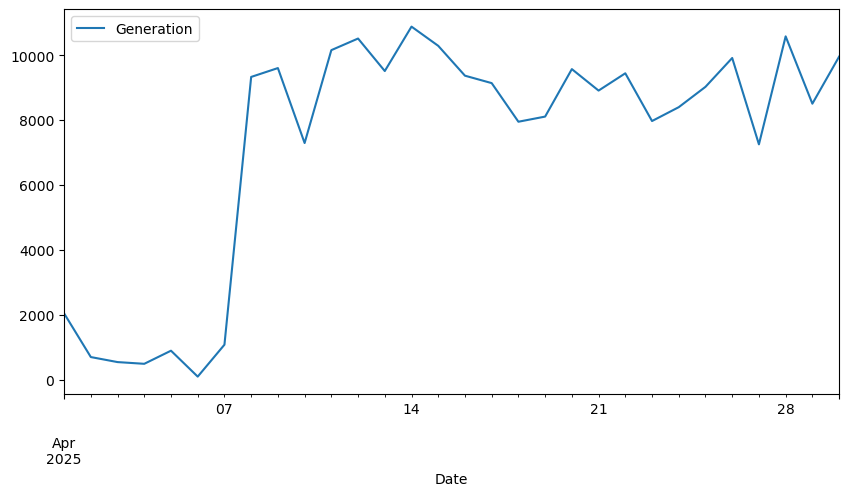

In [19]:
df.plot(x='Date', y='Generation', figsize=(10,5))

## Inverter Level Analysis

In [20]:
inverter_cols = [col for col in df.columns if 'Inverter' in col]

df[inverter_cols] = df[inverter_cols].apply(pd.to_numeric, errors='coerce')

In [21]:
df[inverter_cols] = df[inverter_cols].fillna(0)

### Total energy generated by each inverter in April

In [22]:
inv_sum = df[inverter_cols].sum().sort_values()

print(inv_sum)

Inverter 9         0.00
Inverter 3     11750.50
Inverter 2     11838.32
Inverter 5     12049.59
Inverter 6     12293.72
Inverter 12    12409.10
Inverter 13    12437.79
Inverter 10    12456.22
Inverter 1     12648.50
Inverter 7     12648.73
Inverter 11    12689.64
Inverter 4     12693.92
Inverter 16    12696.73
Inverter 15    12704.59
Inverter 14    12738.21
Inverter 8     12848.85
Inverter 17    12867.43
Inverter 18    13103.59
dtype: float64


### **Insight 1**- Inverter 9 shows zero generation throughout the month, indicating a complete outage or data unavailability. This is a major contributor to overall plant underperformance.

#### Lowest (excluding inverter 9): 11,750 kWh
#### Highest: 13,103 kWh
#### Difference ≈ ~11–12%

### **Insight 2**- Significant variation (~10–12%) observed across inverters, indicating possible mismatch, uneven loading, or localized shading effects.

## Quantifying loss due to Inverter 9-

In [24]:
# Confirming Inverter 9 Outage 
df[df['Inverter 9'] == 0][['Date', 'Inverter 9']]

,Date,Inverter 9
0,2025-04-01,0.0
1,2025-04-02,0.0
2,2025-04-03,0.0
3,2025-04-04,0.0
4,2025-04-05,0.0
5,2025-04-06,0.0
6,2025-04-07,0.0
7,2025-04-08,0.0
8,2025-04-09,0.0
9,2025-04-10,0.0


In [25]:
# Percentage contribution of each inverter
inv_percent = (inv_sum / inv_sum.sum()) * 100
print(inv_percent)

Inverter 9     0.000000
Inverter 3     5.519895
Inverter 2     5.561149
Inverter 5     5.660395
Inverter 6     5.775077
Inverter 12    5.829278
Inverter 13    5.842755
Inverter 10    5.851413
Inverter 1     5.941738
Inverter 7     5.941846
Inverter 11    5.961064
Inverter 4     5.963074
Inverter 16    5.964394
Inverter 15    5.968087
Inverter 14    5.983880
Inverter 8     6.035854
Inverter 17    6.044582
Inverter 18    6.155520
dtype: float64


### Excluding Inverter 9, all other inverters contribute roughly 5.5–6.2% each to total monthly generation. Inverter 9 contributes 0%, confirming a complete outage and highlighting a major system-level issue.

In [30]:
# Total energy lost due to Inverter 9
# Total plant generation = 217,515.8 kWh
# Most other inverters contribute ~5.5–6.1%
# Let’s take average ~5.9% as expected contribution for Inverter 9
inv_avg_percent = inv_percent.drop('Inverter 9').mean()  # ~5.9%
inv_9_expected = total_gen * inv_avg_percent / 100
inv_9_expected = 217515.8 * 5.9 / 100
print("Expected Generation for Inverter 9:", inv_9_expected)

Expected Generation for Inverter 9: 12833.4322


In [32]:
# Quantify CUF Impact-
cuf_corrected = (total_gen + inv_9_expected) / (capacity * 24 * days)
cuf_corrected

np.float64(0.1367220039173789)

### CUF could have increased from 12.9% → 13.7% if Inverter 9 was operational, showing a significant single-inverter impact.

### Core Analysis and Automation below-

In [33]:
import pandas as pd

In [34]:
# Loading excel file and listing all sheet names
file = 'Copy of PPT 25-26.xlsx'
xls = pd.ExcelFile(file)
sheet_names = xls.sheet_names
print(sheet_names)

['Master', 'GHI distribution', 'Apr-25', 'May-25', 'Jun-25', 'July-2025', 'Aug-2025', 'Sep-25', 'Oct-25', 'Nov-25']


In [35]:
# Excluding master sheet as only month sheets are required for analysis
monthly_sheets = [sheet for sheet in sheet_names if '25' in sheet or '2025' in sheet]
print(monthly_sheets)

['Apr-25', 'May-25', 'Jun-25', 'July-2025', 'Aug-2025', 'Sep-25', 'Oct-25', 'Nov-25']


## Automating across all months-

In [36]:
results = []

In [51]:
for sheet in monthly_sheets:
    # Load the sheet
    df = pd.read_excel(file, sheet_name=sheet, header=2) 
    
    # Clean columns (strip spaces)
    df.columns = df.columns.str.strip()
    
    # Remove any total or summary rows
    df = df[df['Date'] != 'Total']
    
    # Ensure Date is datetime
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])  # Drop any invalid dates
    
    # Rename key columns for consistency
    df = df.rename(columns={
        'Actual Total kWh': 'Generation',
        'GHI kW/m2': 'GHI'
    })
    
    # Convert inverter columns to numeric (in case any strings appear)
    inverter_cols = [col for col in df.columns if 'Inverter' in col]
    df[inverter_cols] = df[inverter_cols].apply(pd.to_numeric, errors='coerce')
    df[inverter_cols] = df[inverter_cols].fillna(0)  # Replace missing values with 0
    
    # Calculate total generation for the month
    total_gen = df['Generation'].sum()
    
    # Calculate total days
    days = df['Date'].nunique()
    
    # Calculate CUF
    capacity = 2340  # As per master sheet
    cuf = total_gen / (capacity * 24 * days)
    
    # Sum inverter generation
    inv_sum = df[inverter_cols].sum()
    
    # Correlation GHI vs Generation
    corr = df[['GHI', 'Generation']].corr().iloc[0, 1]

        # ===== NEW KPIs =====
    
    # 1. PR (approx)
    df['PR_daily'] = df['Generation'] / (df['GHI'] * capacity)
    pr = df['PR_daily'].mean()
    
    # 2. Specific Yield
    specific_yield = total_gen / capacity
    
    # 3. Variability 
    variability = df['Generation'].std()
    
    # Append results for this month
    results.append({
        'Month': sheet,
        'Total Generation': total_gen,
        'CUF': cuf,
        'PR': pr,
        'Specific Yield': specific_yield,
        'GHI vs Generation Corr': corr,
        'Variability': variability,
        'Inverter Sum': inv_sum.to_dict()
    })

In [38]:
# Convert results into a summary DataFrame
summary_df = pd.DataFrame(results)

# Expand inverter sums into separate columns
inverter_df = pd.DataFrame(summary_df['Inverter Sum'].tolist())
summary_df = pd.concat([summary_df, inverter_df], axis=1)

# ===== ADDing new KPI CUF loss% HERE =====
best_cuf = summary_df['CUF'].max()
summary_df['CUF Loss %'] = (best_cuf - summary_df['CUF']) / best_cuf * 100

# ===== THEN PRINT =====
print(summary_df)

       Month  Total Generation       CUF        PR  Specific Yield  \
0     Apr-25         217515.80  0.129105  0.535462       92.955470   
1     May-25         256448.71  0.147303  0.744318      109.593466   
2     Jun-25         247988.59  0.147192  0.797003      105.978030   
3  July-2025         209279.48  0.120209  0.807855       89.435675   
4   Aug-2025         191761.98  0.110147  0.759790       81.949564   
5     Sep-25         210218.40  0.124774  0.800050       89.836923   
6     Oct-25         186375.94  0.107054  0.616004       79.647838   
7     Nov-25         230704.14  0.136933  0.718860       98.591513   

   GHI vs Generation Corr  Variability  \
0                0.049653  3720.060324   
1                0.558283  2229.179555   
2                0.982792  2172.599710   
3                0.908061  1942.202730   
4                0.827191  2715.646673   
5                0.984023  2314.010774   
6                0.549484  3459.951365   
7                0.408798  1648.8

In [39]:
clean_df = summary_df[[
    'Month',
    'Total Generation',
    'CUF',
    'PR',
    'Specific Yield',
    'GHI vs Generation Corr',
    'CUF Loss %'
]].round(3)

clean_df

,Month,Total Generation,CUF,PR,Specific Yield,GHI vs Generation Corr,CUF Loss %
0,Apr-25,217515.80,0.129,0.535,92.955,0.050,12.354
1,May-25,256448.71,0.147,0.744,109.593,0.558,0.000
2,Jun-25,247988.59,0.147,0.797,105.978,0.983,0.076
3,July-2025,209279.48,0.120,0.808,89.436,0.908,18.393
4,Aug-2025,191761.98,0.110,0.760,81.950,0.827,25.224
5,Sep-25,210218.40,0.125,0.800,89.837,0.984,15.295
6,Oct-25,186375.94,0.107,0.616,79.648,0.549,27.324
7,Nov-25,230704.14,0.137,0.719,98.592,0.409,7.040


In [40]:
df[['GHI', 'Generation']].describe()

,GHI,Generation
count,30.000000,30.000000
mean,4.617000,7690.138000
std,0.672387,1648.815531
min,2.660000,259.600000
25%,4.310000,7295.175000
50%,4.805000,7993.750000
75%,5.112500,8653.350000
max,5.560000,9240.710000


### Looking for missing KPIs horizontally to check day wise issues or low generation days-

In [41]:
# Loading of Apr-25 sheet again for checking low generation days and relating it with GHI
df = pd.read_excel(file, sheet_name='Apr-25', header=2)

df.columns = df.columns.str.strip()

df = df[df['Date'] != 'Total']

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])

df = df.rename(columns={
    'Actual Total kWh': 'Generation',
    'GHI kW/m2': 'GHI'
})

In [42]:
df[['Date', 'Generation']].sort_values(by='Generation').head(10)

,Date,Generation
5,2025-04-06,94.00
3,2025-04-04,489.00
2,2025-04-03,542.00
1,2025-04-02,697.00
4,2025-04-05,893.00
6,2025-04-07,1077.83
0,2025-04-01,2043.00
26,2025-04-27,7252.90
9,2025-04-10,7293.40
17,2025-04-18,7950.00


In [43]:
# Cjecking with GHI
df[['Date', 'GHI', 'Generation']].sort_values(by='Generation').head(7)

,Date,GHI,Generation
5,2025-04-06,6.85,94.00
3,2025-04-04,6.62,489.00
2,2025-04-03,2.67,542.00
1,2025-04-02,6.27,697.00
4,2025-04-05,6.42,893.00
6,2025-04-07,6.36,1077.83
0,2025-04-01,6.67,2043.00


In [44]:
# Checking downtime days
downtime_days = df[(df['GHI'] > 5) & (df['Generation'] < 2000)]

len(downtime_days)

5

In [45]:
downtime_days[['Date', 'GHI', 'Generation']]

,Date,GHI,Generation
1,2025-04-02,6.27,697.00
3,2025-04-04,6.62,489.00
4,2025-04-05,6.42,893.00
5,2025-04-06,6.85,94.00
6,2025-04-07,6.36,1077.83


In [46]:
avg_gen = df['Generation'].mean()

downtime_loss = (avg_gen - downtime_days['Generation']).sum()

print("Estimated downtime loss:", downtime_loss)

Estimated downtime loss: 33001.80333333333


## Automating for all months similarly as done for April-

In [47]:
downtime_summary = []

for sheet in monthly_sheets:
    
    df = pd.read_excel(file, sheet_name=sheet, header=2)
    
    df.columns = df.columns.str.strip()
    
    df = df[df['Date'] != 'Total']
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    
    df = df.rename(columns={
        'Actual Total kWh': 'Generation',
        'GHI kW/m2': 'GHI'
    })
    
    # Convert to numeric 
    df['Generation'] = pd.to_numeric(df['Generation'], errors='coerce')
    
    # NEW downtime condition
    downtime_days = df[
        (df['Generation'] < 2000) | (df['Generation'].isna())
    ].copy()

    # Classify reason using GHI
    downtime_days['Reason'] = downtime_days['GHI'].apply(
    lambda x: 'Weather Issue' if x < 3 else 'System Issue'
    )

    weather_days = len(downtime_days[downtime_days['Reason'] == 'Weather Issue'])
    system_days = len(downtime_days[downtime_days['Reason'] == 'System Issue'])

    
    # Calculate loss
    avg_gen = df['Generation'].mean()
    downtime_loss = (avg_gen - downtime_days['Generation'].fillna(0)).sum()
    
    downtime_summary.append({
    'Month': sheet,
    'Downtime Days': len(downtime_days),
    'System Issue Days': system_days,
    'Weather Issue Days': weather_days,
    'Downtime Loss (kWh)': downtime_loss
     })

downtime_df = pd.DataFrame(downtime_summary)

downtime_df

,Month,Downtime Days,System Issue Days,Weather Issue Days,Downtime Loss (kWh)
0,Apr-25,6,5,1,39710.330000
1,May-25,1,1,0,7469.229032
2,Jun-25,0,0,0,0.000000
3,July-2025,0,0,0,0.000000
4,Aug-2025,3,1,2,18006.620968
5,Sep-25,0,0,0,0.000000
6,Oct-25,7,6,1,39036.149677
7,Nov-25,1,1,0,7430.538000


In [48]:
# STEP 1: Detect missing inverter data for June month only
df = pd.read_excel(file, sheet_name='Jun-25', header=2)

df.columns = df.columns.str.strip()

df = df[df['Date'] != 'Total']
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# Check inverter 8 missing
inv8_issue = df[df['Inverter 8'].isna() | (df['Inverter 8'] == 0)]

inv8_issue[['Date', 'Inverter 8']].head(20)

,Date,Inverter 8
4,2025-06-05,NaN
5,2025-06-06,NaN
6,2025-06-07,NaN
7,2025-06-08,NaN
8,2025-06-09,NaN
9,2025-06-10,NaN
10,2025-06-11,NaN
11,2025-06-12,NaN
12,2025-06-13,NaN
13,2025-06-14,NaN


In [49]:
# STEP 2: Counting of affected days
len(inv8_issue)

13

In [50]:
# Step-3 Estimate loss
avg_inv8 = df['Inverter 8'].mean()

inv8_loss = avg_inv8 * len(inv8_issue)

print(inv8_loss)

6360.617058823531


### Above Inverter 8 exhibited a continuous outage from 5th to 17th June (12 days), leading to estimated energy loss. This indicates inverter-level fault or communication failure.